In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, confusion_matrix

from xgboost import XGBClassifier
import shap
from scipy.stats import ks_2samp
import pickle

In [2]:
#LOAD DATA
from google.colab import files
uploaded = files.upload()

Saving diabetes_prediction_dataset.csv to diabetes_prediction_dataset.csv


In [3]:
df = pd.read_csv("diabetes_prediction_dataset.csv")
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [4]:
#3. BASIC EDA
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


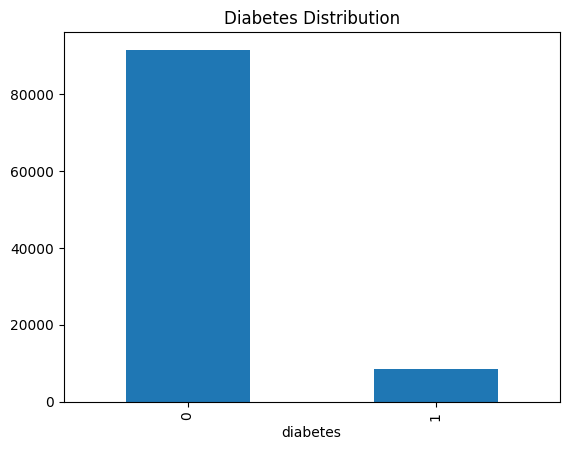

In [5]:
df['diabetes'].value_counts().plot(kind='bar')
plt.title("Diabetes Distribution")
plt.show()

Insight: Check imbalance

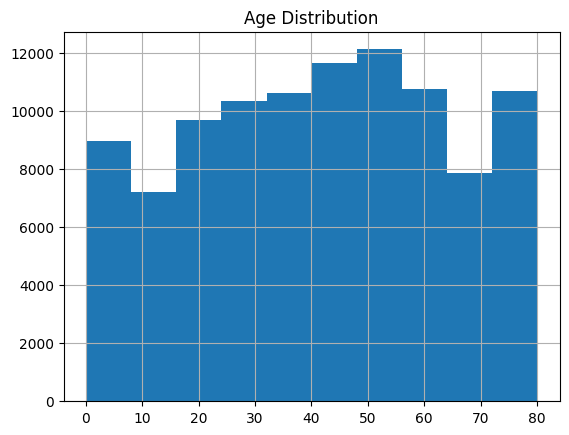

In [6]:
#Age Distribution
df['age'].hist()
plt.title("Age Distribution")
plt.show()

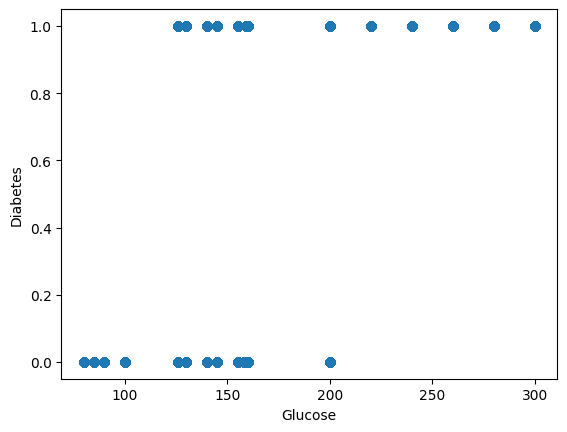

In [7]:
#Glucose vs Diabetes
plt.scatter(df['blood_glucose_level'], df['diabetes'])
plt.xlabel("Glucose")
plt.ylabel("Diabetes")
plt.show()

Higher glucose → higher diabetes

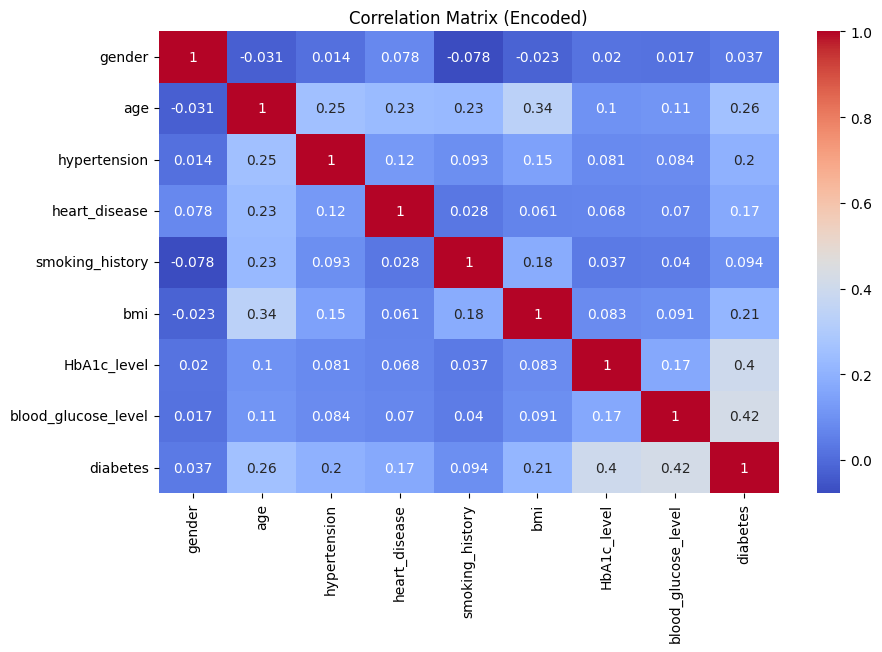

In [11]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

le = LabelEncoder()

df_encoded['gender'] = le.fit_transform(df_encoded['gender'])
df_encoded['smoking_history'] = le.fit_transform(df_encoded['smoking_history'])

plt.figure(figsize=(10,6))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix (Encoded)")


plt.show()

Strong predictors of diabetes:
blood_glucose_level (0.42)
HbA1c_level (0.40)
Moderate impact features:
age (0.26)
bmi (0.21)
hypertension (0.20)
heart_disease (0.17)
Weak impact features:
smoking_history (0.09)
gender (0.04)
Feature relationships:
age is moderately correlated with bmi, hypertension, and heart_disease
No multicollinearity:
No very high correlations → model will be stable

**DATA** PREPROCESSING

In [12]:
df['gender'] = df['gender'].map({'Male':0, 'Female':1, 'Other':2})
df['smoking_history'] = df['smoking_history'].astype('category').cat.codes

In [13]:
#HANDLE CLASS IMBALANCE
df_major = df[df.diabetes == 0]
df_minor = df[df.diabetes == 1]

df_minor_up = resample(df_minor, replace=True, n_samples=len(df_major))
df_bal = pd.concat([df_major, df_minor_up])

In [14]:
#SPLIT DATA
X = df_bal.drop('diabetes', axis=1)
y = df_bal['diabetes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [15]:
#Train Model (XGBoost)
model = XGBClassifier(eval_metric='logloss')
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [16]:
#Evaluation
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.9399726775956284
Recall: 0.959830866807611
ROC-AUC: 0.9884576997892883


In [17]:
#Risk Scoring
risk_score = (y_prob * 100).astype(int)

df_out = X_test.copy()
df_out['Actual'] = y_test
df_out['Prediction'] = y_pred
df_out['Risk Score'] = risk_score

**Explainable AI using SHAP**

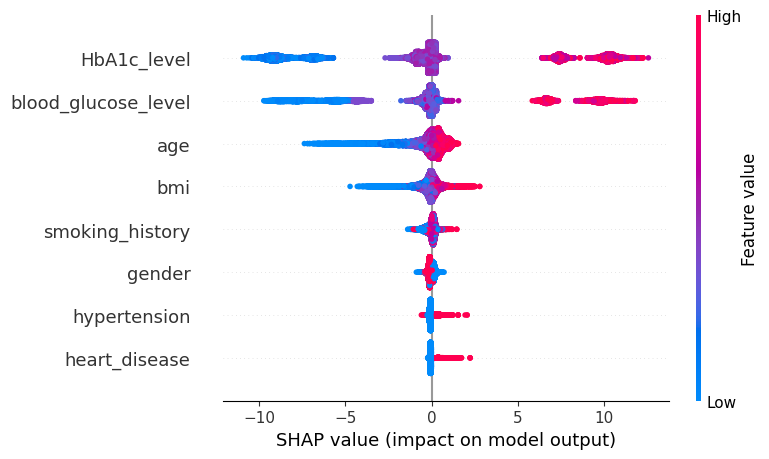

In [18]:
#SHAP Explainability
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

**Insights**:SHAP analysis shows that HbA1c level and blood glucose level are the most influential features driving model predictions. Higher values of these significantly increase diabetes risk. Age and BMI have moderate influence, while gender and smoking history have minimal impact. This confirms that the model is learning medically relevant patterns.

In [26]:
# Individual Prediction Explanation
print(type(shap_values))
print(len(shap_values))
import shap
shap.initjs()

# Select one sample
sample = 0

shap.plots.force(
    explainer.expected_value,
    shap_values[sample],
    X_test.iloc[sample]
)


<class 'numpy.ndarray'>
36600


**Insights:**

Final result is high (9.95)
So the model thinks this person likely has

1. Final result is high (9.95)
So the model thinks this person likely has diabetes
2.There is a starting point (base value)
Like an average guess for any person
3. Some factors push the result higher (red side)
Here, HbA1c = 6.8 is pushing strongly toward diabetes
4. Some factors push the result lower (blue side)Like blood glucose, but effect is smaller here
5. Final decision
The “high-risk” factors are stronger → so prediction = diabetes





**Data** **Drift** **Detection**

In [27]:
#Data Drift Detection (Compare Train vs Test distribution)
from scipy.stats import ks_2samp

drift_results = {}

for col in X_train.columns:
    stat, p_value = ks_2samp(X_train[col], X_test[col])

    drift_results[col] = p_value

# Show drifted features
for feature, p in drift_results.items():
    if p < 0.05:
        print(f"⚠️ Drift detected in {feature} (p={p})")

⚠️ Drift detected in bmi (p=0.027449928837318893)


In [28]:
# Simulate new data (use test as "future data")
y_pred_new = model.predict(X_test)

from sklearn.metrics import accuracy_score

acc_old = accuracy_score(y_train, model.predict(X_train))
acc_new = accuracy_score(y_test, y_pred_new)

print("Train Accuracy:", acc_old)
print("New Data Accuracy:", acc_new)

if acc_new < acc_old - 0.05:
    print("⚠️ Concept Drift Detected!")

Train Accuracy: 0.9454303278688525
New Data Accuracy: 0.9399726775956284


In [30]:
import numpy as np

old_data = df.copy()
new_data = df.copy()

# Artificial drift in BMI
new_data['bmi'] = new_data['bmi'] + np.random.normal(2, 1, size=len(df))

from scipy.stats import ks_2samp

stat, p_value = ks_2samp(old_data['bmi'], new_data['bmi'])

print("P-value:", p_value)

if p_value < 0.05:
    print("⚠️ Drift detected in BMI")
else:
    print("✅ No drift")

P-value: 0.0
⚠️ Drift detected in BMI


In [31]:
#Retraining the Model
# Combine old + new data
df_updated = pd.concat([old_data, new_data])

# Split again
X = df_updated.drop('diabetes', axis=1)
y = df_updated['diabetes']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Retrain model
model.fit(X_train, y_train)

# Check accuracy
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)

print("Updated Accuracy:", accuracy_score(y_test, y_pred))

Updated Accuracy: 0.972625


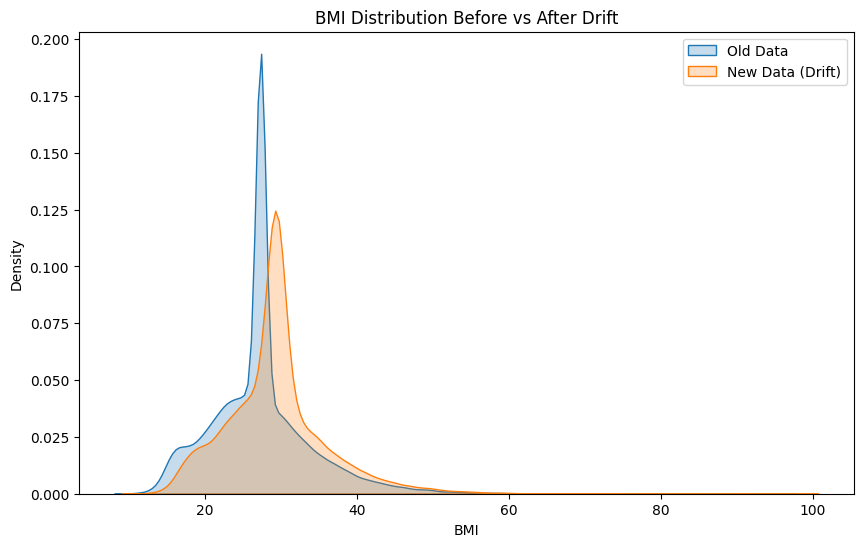

In [32]:
#Before vs After Drift Graph VERY IMPORTANT
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.kdeplot(old_data['bmi'], label='Old Data', fill=True)
sns.kdeplot(new_data['bmi'], label='New Data (Drift)', fill=True)

plt.title("BMI Distribution Before vs After Drift")
plt.xlabel("BMI")
plt.ylabel("Density")
plt.legend()
plt.show()

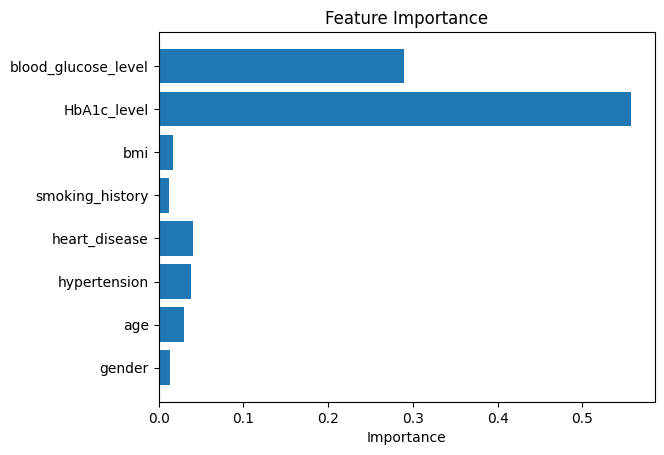

In [33]:
#Feature Importance Plot
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()

In [34]:
import pickle

with open("diabetes_model.pkl", "wb") as f:
    pickle.dump(model, f)

**Simple Deployment (Streamlit)**

In [35]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 45.6 MB/s eta 0:00:00


In [38]:

import streamlit as st
import pickle
import numpy as np

model = pickle.load(open("diabetes_model.pkl", "rb"))

st.title("Diabetes Prediction System")

age = st.slider("Age", 1, 100)
bmi = st.number_input("BMI")
glucose = st.number_input("Blood Glucose Level")
hba1c = st.number_input("HbA1c Level")

if st.button("Predict"):
    data = np.array([[0, age, 0, 0, 0, bmi, hba1c, glucose]])
    pred = model.predict(data)

    if pred[0] == 1:
        st.error("Diabetic")
    else:
        st.success("Non-Diabetic")

2026-03-30 10:24:57.048 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 10:24:57.055 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 10:24:57.057 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 10:24:57.062 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 10:24:57.067 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 10:24:57.071 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 10:24:57.076 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 10:24:57.083 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [40]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))

from google.colab import files
files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
X_full = df.drop("diabetes", axis=1)

pred = model.predict(X_full)
prob = model.predict_proba(X_full)[:,1]

df['prediction'] = pred
df['risk_score'] = prob

df.to_csv("risk_scored_output.csv", index=False)